<a href="https://colab.research.google.com/github/YusufG10/ProgramlamaDilleri/blob/main/makinefinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

# --- 1.1. Wine veri setinin yüklenmesi ---
# Özellik matrisi X ve sınıf etiketleri y elde edilir
wine = load_wine()
X = wine.data
y = wine.target

# Temel istatistiklerin raporlanması
n_samples = X.shape[0]        # Örnek sayısı
n_features = X.shape[1]       # Öznitelik sayısı
n_classes = len(np.unique(y)) # Sınıf sayısı

print("--- Bölüm 1.1: Wine Veri Seti İstatistikleri ---")
print(f"Örnek Sayısı: {n_samples}")
print(f"Öznitelik Sayısı: {n_features}")
print(f"Sınıf Sayısı: {n_classes}")

# --- 1.2. Veri setinin %80 train %20 test olarak ayrılması ---
# Veri seti belirtilen oranda bölünür
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("\n--- Bölüm 1.2: Alt Küme Boyutları ---")
print(f"X_train boyutu: {X_train.shape}")
print(f"X_test boyutu: {X_test.shape}")
print(f"y_train boyutu: {y_train.shape}")
print(f"y_test boyutu: {y_test.shape}")

# --- 1.3. Normalizasyon / Standardizasyon ---
# Hazır fonksiyon kullanmadan açık bir fonksiyon yazılır
def my_standardization(train_data, test_data):
    # Ortalama (mu) ve standart sapma (sigma) eğitim verisi üzerinden hesaplanır
    mu = np.mean(train_data, axis=0)
    sigma = np.std(train_data, axis=0)

    # Formül: (X - mu) / sigma
    # İşlem hem eğitim hem test verisine uygulanır
    train_scaled = (train_data - mu) / sigma
    test_scaled = (test_data - mu) / sigma

    return train_scaled, test_scaled

# Normalizasyonun uygulanması
X_train_scaled, X_test_scaled = my_standardization(X_train, X_test)

# Beklenen sonuç kontrolü: mean = 0.000, std = 1.000
print("\n--- Bölüm 1.3: Normalizasyon Kontrolü (Eğitim Verisi) ---")
print(f"Ortalama (Mean) (Beklenen 0.0): {np.mean(X_train_scaled, axis=0).mean().round(3)}")
print(f"Standart Sapma (Std) (Beklenen 1.0): {np.std(X_train_scaled, axis=0).mean().round(3)}")

--- Bölüm 1.1: Wine Veri Seti İstatistikleri ---
Örnek Sayısı: 178
Öznitelik Sayısı: 13
Sınıf Sayısı: 3

--- Bölüm 1.2: Alt Küme Boyutları ---
X_train boyutu: (142, 13)
X_test boyutu: (36, 13)
y_train boyutu: (142,)
y_test boyutu: (36,)

--- Bölüm 1.3: Normalizasyon Kontrolü (Eğitim Verisi) ---
Ortalama (Mean) (Beklenen 0.0): 0.0
Standart Sapma (Std) (Beklenen 1.0): 1.0


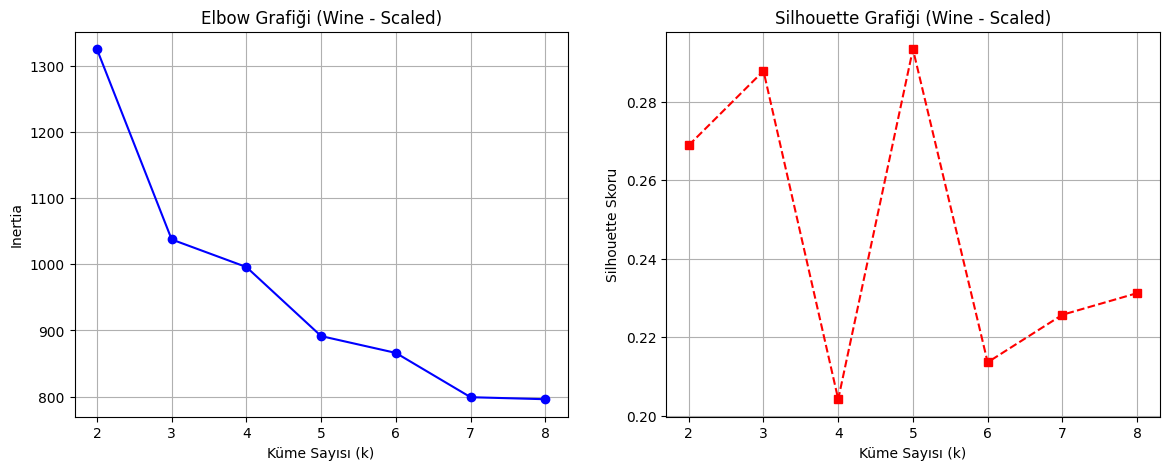

In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt

# 2.1. Küme sayısı aralığının belirlenmesi
k_min = 2
k_true = 3  # Wine veri setinde 3 sınıf (etiket) vardır
n_train = X_train_scaled.shape[0]

# Formül: k_max = k_true + [log(n_train)]
k_max = k_true + math.ceil(math.log(n_train))
k_range = range(k_min, k_max + 1)

# 2.2. K-Means Algoritmasının Açık Biçimde Yazılması (my_kmeans)
def my_kmeans(X, k, max_iters=100):
    n_samples, n_features = X.shape

    # Eğitim verisinden rastgele k örneğin seçilerek başlangıç merkezlerinin oluşturulması
    indices = np.random.choice(n_samples, k, replace=False)
    centroids = X[indices]

    for _ in range(max_iters):
        # Her örneğin en yakın merkeze atanması
        # Öklid uzaklığı hesaplanır
        distances = np.sqrt(((X[:, np.newaxis] - centroids)**2).sum(axis=2))
        labels = np.argmin(distances, axis=1)

        # Küme merkezlerinin güncellenmesi
        new_centroids = np.array([X[labels == i].mean(axis=0) if len(X[labels == i]) > 0
                                 else centroids[i] for i in range(k)])

        # Merkezler yakınsadığında (değişmediğinde) iterasyonun durdurulması
        if np.all(centroids == new_centroids):
            break
        centroids = new_centroids

    # Inertia hesaplama (Küme içi kareler toplamı)
    inertia = 0
    for i in range(k):
        if len(X[labels == i]) > 0:
            inertia += np.sum((X[labels == i] - centroids[i])**2)

    return labels, centroids, inertia

# 2.3. Silhouette Skorunun Açık Biçimde Yazılması (my_silhouette_score)
def my_silhouette_score(X, labels):
    n = len(X)
    unique_labels = np.unique(labels)
    if len(unique_labels) < 2: return 0

    s_scores = []
    for i in range(n):
        # a(i): i'nin kendi kümesindeki diğer noktalara ortalama uzaklığı
        own_cluster = X[labels == labels[i]]
        if len(own_cluster) > 1:
            a_i = np.mean(np.linalg.norm(own_cluster - X[i], axis=1))
        else:
            a_i = 0

        # b(i): i'nin en yakın olduğu (kendi kümesi dışındaki) kümeye ortalama uzaklığı
        b_i = float('inf')
        for label in unique_labels:
            if label == labels[i]: continue
            other_cluster = X[labels == label]
            avg_dist = np.mean(np.linalg.norm(other_cluster - X[i], axis=1))
            b_i = min(b_i, avg_dist)

        # s(i) silhouette tanımı
        s_i = (b_i - a_i) / max(a_i, b_i)
        s_scores.append(s_i)

    return np.mean(s_scores)

# 2.4. Elbow ve Silhouette Grafiklerinin Çizilmesi
inertias = []
silhouettes = []

for k in k_range:
    labels, centers, inertia = my_kmeans(X_train_scaled, k)
    score = my_silhouette_score(X_train_scaled, labels)

    inertias.append(inertia)
    silhouettes.append(score)

# Görselleştirme
plt.figure(figsize=(14, 5))

# Elbow Grafiği (k-Inertia)
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, marker='o', linestyle='-', color='b')
plt.title('Elbow Grafiği (Wine - Scaled)')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Inertia')
plt.grid(True)

# Silhouette Grafiği (k-Silhouette)
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouettes, marker='s', linestyle='--', color='r')
plt.title('Silhouette Grafiği (Wine - Scaled)')
plt.xlabel('Küme Sayısı (k)')
plt.ylabel('Silhouette Skoru')
plt.grid(True)

plt.show()

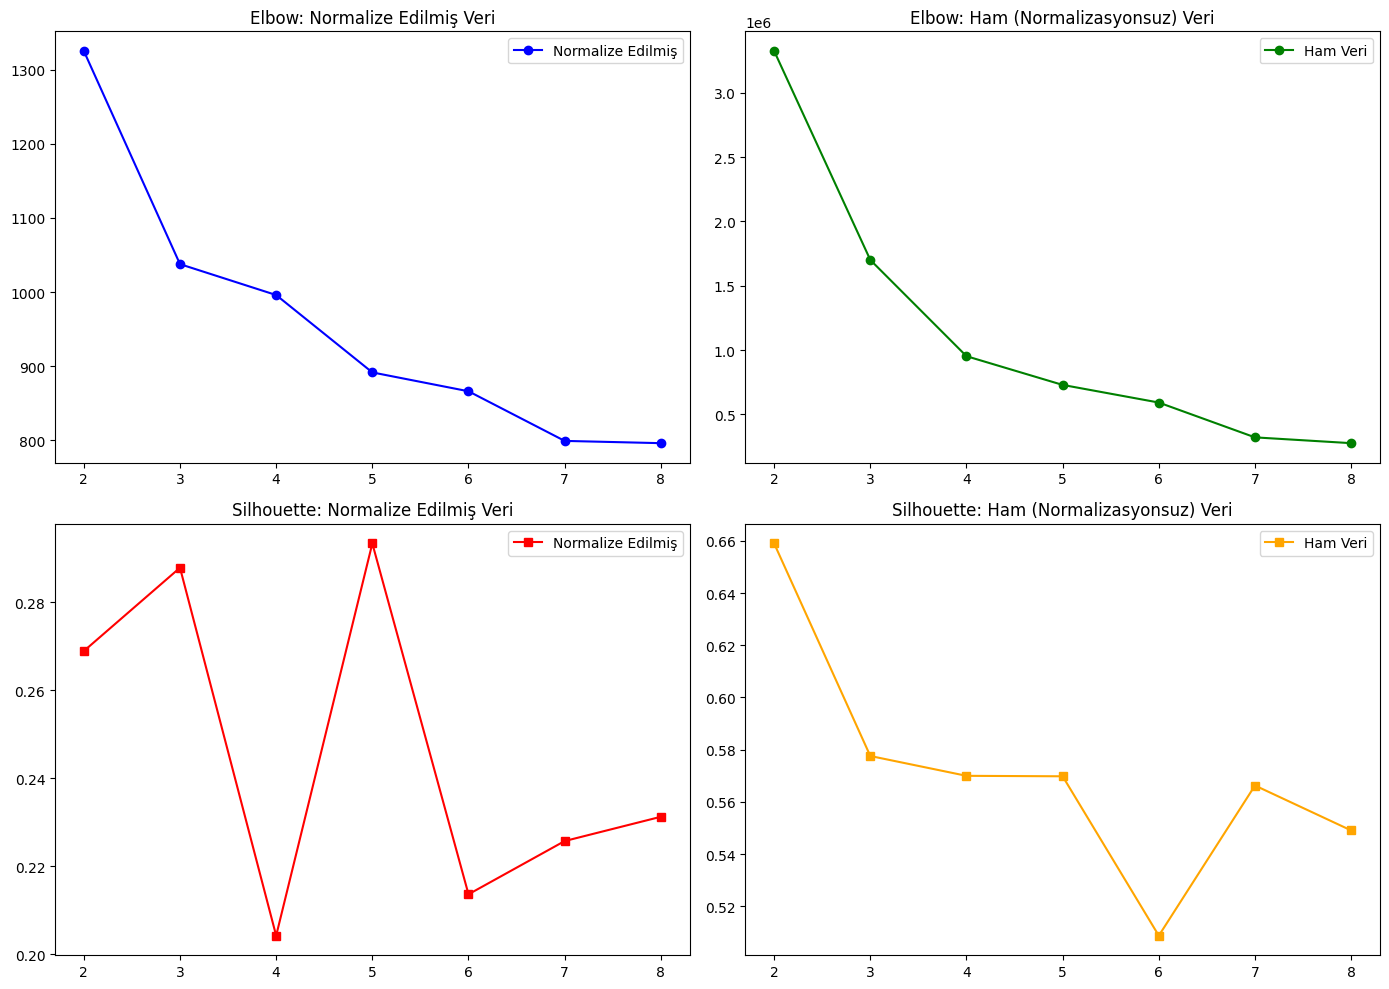

In [ ]:
import matplotlib.pyplot as plt

# --- 3.1. Normalizasyonsuz Analiz Hazırlığı ---
# Bu bölümde X_train_scaled yerine ham X_train kullanılacaktır.
inertias_raw = []
silhouettes_raw = []

# Bölüm 2'deki k_range (2'den 8'e kadar) aynen kullanılır.
for k in k_range:
    # K-Means eğitimi ham veri (X_train) üzerinde yapılır
    labels_raw, centers_raw, inertia_raw = my_kmeans(X_train, k)

    # Silhouette skoru ham veri üzerinden hesaplanır
    score_raw = my_silhouette_score(X_train, labels_raw)

    inertias_raw.append(inertia_raw)
    silhouettes_raw.append(score_raw)

# --- 3.2. Sonuçların Grafiksel Karşılaştırılması ---
plt.figure(figsize=(14, 10))

# 1. Elbow Grafiği Karşılaştırması
plt.subplot(2, 2, 1)
plt.plot(k_range, inertias, marker='o', color='b', label='Normalize Edilmiş')
plt.title('Elbow: Normalize Edilmiş Veri')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(k_range, inertias_raw, marker='o', color='g', label='Ham Veri')
plt.title('Elbow: Ham (Normalizasyonsuz) Veri')
plt.legend()

# 2. Silhouette Grafiği Karşılaştırması
plt.subplot(2, 2, 3)
plt.plot(k_range, silhouettes, marker='s', color='r', label='Normalize Edilmiş')
plt.title('Silhouette: Normalize Edilmiş Veri')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(k_range, silhouettes_raw, marker='s', color='orange', label='Ham Veri')
plt.title('Silhouette: Ham (Normalizasyonsuz) Veri')
plt.legend()

plt.tight_layout()
plt.show()

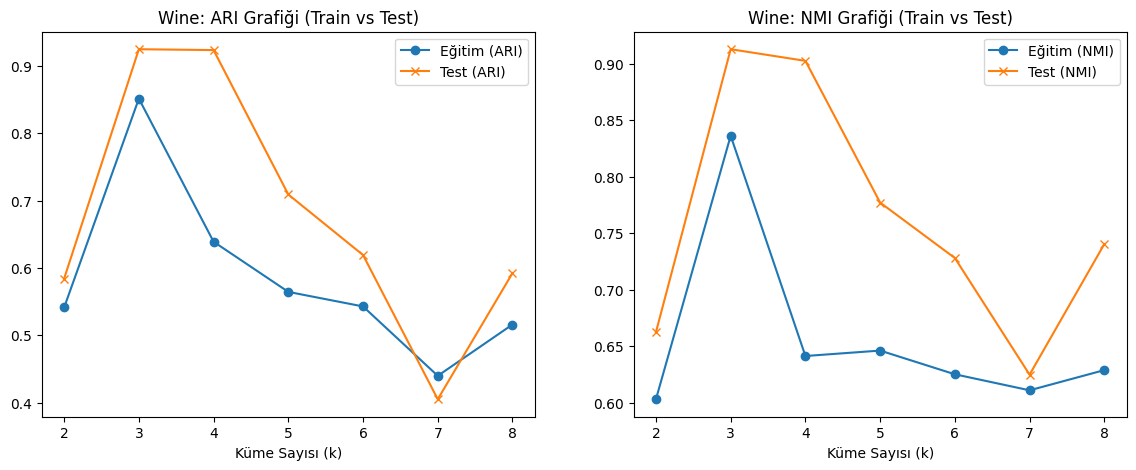

In [ ]:
from sklearn.metrics import normalized_mutual_info_score
import numpy as np
import matplotlib.pyplot as plt

# --- 4.2. ARI'nin Açık Biçimde Yazılması (my_ari) ---
def n_choose_2(n):
    """n elemanlı bir kümeden 2 eleman seçme kombinasyonu: n*(n-1)/2"""
    return (n * (n - 1)) / 2 if n >= 2 else 0

def my_ari(y_true, y_pred):
    # 1. Kontenjans Tablosu (Hata Matrisi) oluşturma
    classes = np.unique(y_true)
    clusters = np.unique(y_pred)

    # n_ij: i sınıfındaki ve j kümesindeki örnek sayısı
    contingency = np.zeros((len(classes), len(clusters)))
    for i in range(len(y_true)):
        class_idx = np.where(classes == y_true[i])[0][0]
        cluster_idx = np.where(clusters == y_pred[i])[0][0]
        contingency[class_idx, cluster_idx] += 1

    # 2. Formül Bileşenleri
    # Index: Hücrelerdeki n_ij'lerin 2'li kombinasyon toplamı
    index = np.sum([n_choose_2(n_ij) for n_ij in contingency.flatten()])

    # Satır ve Sütun toplamlarının 2'li kombinasyonları
    sum_ai_2 = np.sum([n_choose_2(row_sum) for row_sum in np.sum(contingency, axis=1)])
    sum_bj_2 = np.sum([n_choose_2(col_sum) for col_sum in np.sum(contingency, axis=0)])

    n = len(y_true)
    # ExpectedIndex (Beklenen İndeks)
    expected_index = (sum_ai_2 * sum_bj_2) / n_choose_2(n)

    # MaxIndex (Maksimum İndeks)
    max_index = 0.5 * (sum_ai_2 + sum_bj_2)

    # 3. ARI Hesaplama
    if max_index == expected_index: return 0 # Payda sıfır olmasın diye
    ari_score = (index - expected_index) / (max_index - expected_index)

    return ari_score

# --- 4.1 & 4.4. K-Means Eğitimi, Test Ataması ve Grafikleme ---
ari_train_list, ari_test_list = [], []
nmi_train_list, nmi_test_list = [], []

for k in k_range:
    # Eğitim verisi üzerinde model eğitilir
    labels_train, centroids, _ = my_kmeans(X_train_scaled, k)

    # Test verisi eğitimden elde edilen merkezlere atanır
    test_distances = np.sqrt(((X_test_scaled[:, np.newaxis] - centroids)**2).sum(axis=2))
    labels_test = np.argmin(test_distances, axis=1)

    # ARI ve NMI hesaplamaları
    ari_train_list.append(my_ari(y_train, labels_train))
    ari_test_list.append(my_ari(y_test, labels_test))

    nmi_train_list.append(normalized_mutual_info_score(y_train, labels_train))
    nmi_test_list.append(normalized_mutual_info_score(y_test, labels_test))

# --- Grafiklerin Çizilmesi  ---
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, ari_train_list, marker='o', label='Eğitim (ARI)')
plt.plot(k_range, ari_test_list, marker='x', label='Test (ARI)')
plt.title('Wine: ARI Grafiği (Train vs Test)')
plt.xlabel('Küme Sayısı (k)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(k_range, nmi_train_list, marker='o', label='Eğitim (NMI)')
plt.plot(k_range, nmi_test_list, marker='x', label='Test (NMI)')
plt.title('Wine: NMI Grafiği (Train vs Test)')
plt.xlabel('Küme Sayısı (k)')
plt.legend()

plt.show()

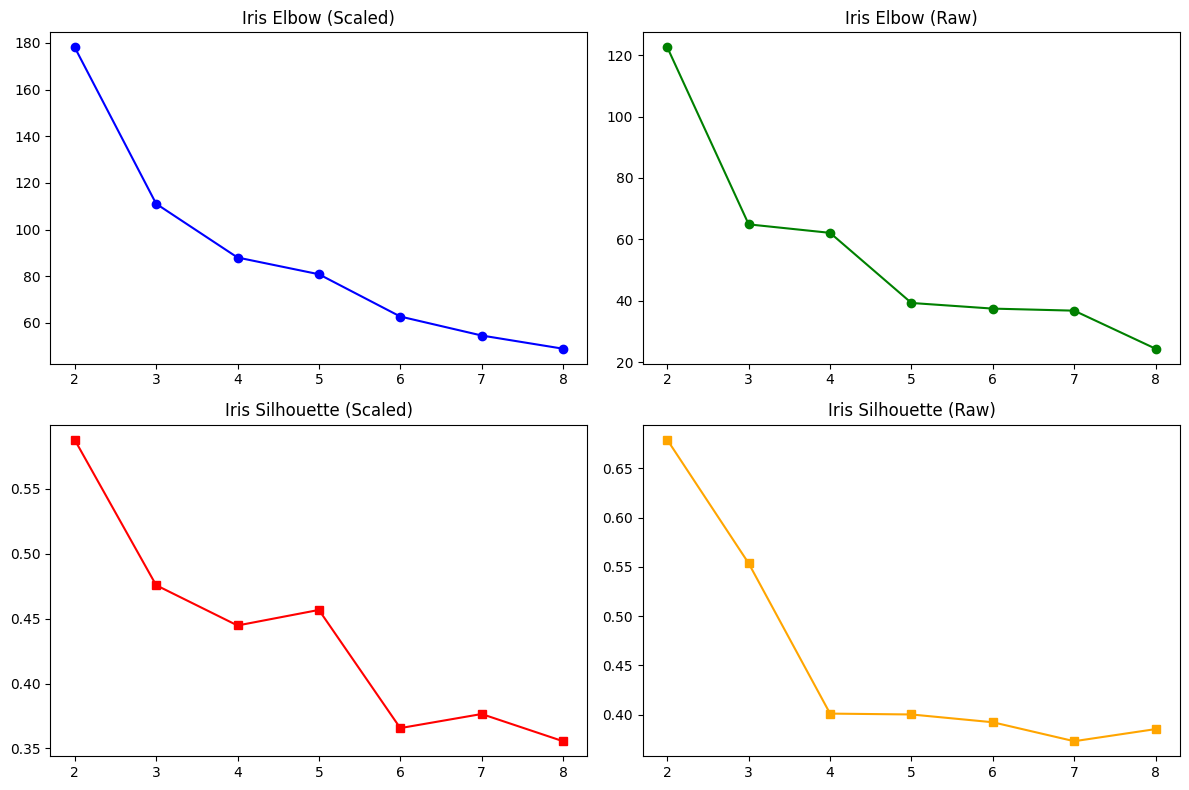

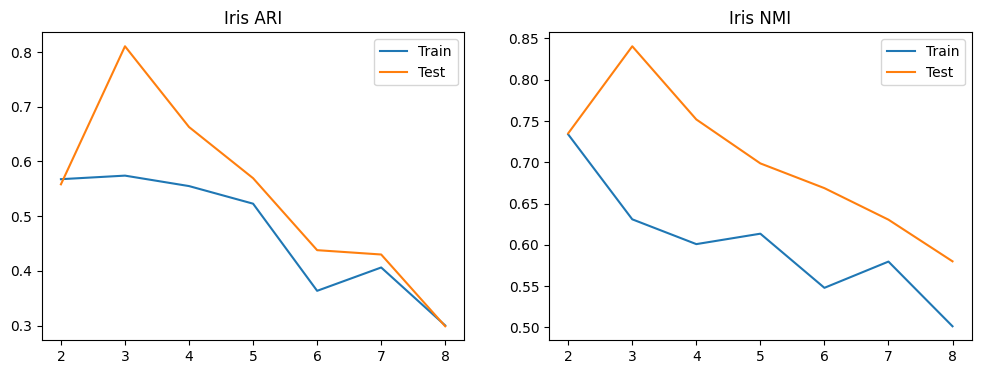

In [ ]:
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import math

# --- 5.1. Veri Yükleme, Train/Test Ayrımı ve Normalizasyon ---
# Iris veri seti yüklenir
iris = load_iris()
X_i, y_i = iris.data, iris.target

# %80 Eğitim, %20 Test ayrımı
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_i, y_i, test_size=0.20, random_state=42)

# Manuel Normalizasyon (Eğitim verisi istatistikleri ile)
X_train_s_i, X_test_s_i = my_standardization(X_train_i, X_test_i)

# --- 5.2. K-Means, Elbow ve Silhouette (Normalizasyonlu ve Normalizasyonsuz) ---
k_max_i = 3 + math.ceil(math.log(len(X_train_i)))
k_range_i = range(2, k_max_i + 1)

iris_results = {'s_ine': [], 's_sil': [], 'r_ine': [], 'r_sil': [],
                'ari_tr': [], 'ari_ts': [], 'nmi_tr': [], 'nmi_ts': []}

for k in k_range_i:
    # Normalizasyonlu Kümeleme
    lab_s, centers_s, ine_s = my_kmeans(X_train_s_i, k)
    iris_results['s_ine'].append(ine_s)
    iris_results['s_sil'].append(my_silhouette_score(X_train_s_i, lab_s))

    # Normalizasyonsuz Kümeleme
    lab_r, _, ine_r = my_kmeans(X_train_i, k)
    iris_results['r_ine'].append(ine_r)
    iris_results['r_sil'].append(my_silhouette_score(X_train_i, lab_r))

    # --- 5.3. ARI ve NMI Analizleri (Train/Test) ---
    # Eğitim ARI/NMI
    iris_results['ari_tr'].append(my_ari(y_train_i, lab_s))
    iris_results['nmi_tr'].append(normalized_mutual_info_score(y_train_i, lab_s))

    # Test verisinin atanması ve Test ARI/NMI
    test_dists = np.sqrt(((X_test_s_i[:, np.newaxis] - centers_s)**2).sum(axis=2))
    lab_ts = np.argmin(test_dists, axis=1)
    iris_results['ari_ts'].append(my_ari(y_test_i, lab_ts))
    iris_results['nmi_ts'].append(normalized_mutual_info_score(y_test_i, lab_ts))

# --- 5.4. Görselleştirme ---
# İçsel Değerlendirme Grafikleri
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0,0].plot(k_range_i, iris_results['s_ine'], 'b-o'); ax[0,0].set_title("Iris Elbow (Scaled)")
ax[0,1].plot(k_range_i, iris_results['r_ine'], 'g-o'); ax[0,1].set_title("Iris Elbow (Raw)")
ax[1,0].plot(k_range_i, iris_results['s_sil'], 'r-s'); ax[1,0].set_title("Iris Silhouette (Scaled)")
ax[1,1].plot(k_range_i, iris_results['r_sil'], 'orange', marker='s'); ax[1,1].set_title("Iris Silhouette (Raw)")
plt.tight_layout(); plt.show()

# Dışsal Değerlendirme Grafikleri
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(k_range_i, iris_results['ari_tr'], label='Train'); plt.plot(k_range_i, iris_results['ari_ts'], label='Test'); plt.title("Iris ARI"); plt.legend()
plt.subplot(1, 2, 2); plt.plot(k_range_i, iris_results['nmi_tr'], label='Train'); plt.plot(k_range_i, iris_results['nmi_ts'], label='Test'); plt.title("Iris NMI"); plt.legend()
plt.show()